<a href="https://colab.research.google.com/github/charlottejocelynne/indobert-vs-mbert-for-indonesian-hoax-news-detection/blob/main/MBERT-finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import io

df1 = df1 = pd.read_csv('/content/undersampled_dataset_1.csv')

# Pembagian Data

In [ ]:
from sklearn.model_selection import train_test_split
import random

In [ ]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 22.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
df_shuffled = df1.sample(frac=1)

In [ ]:
from datasets import DatasetDict, Dataset

In [ ]:
df_label_0 = df_shuffled[df_shuffled['label'] == 0]
df_label_1 = df_shuffled[df_shuffled['label'] == 1]

In [ ]:
# Fraksi data
train_frac = 0.7
valid_frac = 0.15
test_frac = 0.15

# Hitung ukuran untuk setiap subset berdasarkan label
train_size_0 = int(train_frac * len(df_label_0))
valid_size_0 = int(valid_frac * len(df_label_0))

train_size_1 = int(train_frac * len(df_label_1))
valid_size_1 = int(valid_frac * len(df_label_1))

# Split data label 0
train_0 = df_label_0[:train_size_0]
valid_0 = df_label_0[train_size_0:train_size_0 + valid_size_0]
test_0 = df_label_0[train_size_0 + valid_size_0:]

# Split data label 1
train_1 = df_label_1[:train_size_1]
valid_1 = df_label_1[train_size_1:train_size_1 + valid_size_1]
test_1 = df_label_1[train_size_1 + valid_size_1:]


In [ ]:
# Gabungkan data
train_df = pd.concat([train_0, train_1]).sample(frac=1, random_state=42).reset_index(drop=True)
valid_df = pd.concat([valid_0, valid_1]).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
from datasets import Dataset, DatasetDict

# Konversi ke Hugging Face Dataset
train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)
test_ds = Dataset.from_pandas(test_df)

# Gabungkan menjadi DatasetDict
dataset = DatasetDict({
    'train': train_ds,
    'validation': valid_ds,
    'test': test_ds
})


In [ ]:
from datasets import Dataset, DatasetDict

# Konversi ke Hugging Face Dataset
train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)
test_ds = Dataset.from_pandas(test_df)

# Gabungkan menjadi DatasetDict
dataset = DatasetDict({
    'train': train_ds,
    'validation': valid_ds,
    'test': test_ds
})


In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1826
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 390
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 394
    })
})

In [ ]:
print("Distribusi label di train:")
print(train_df['label'].value_counts())

print("\nDistribusi label di validation:")
print(valid_df['label'].value_counts())

print("\nDistribusi label di test:")
print(test_df['label'].value_counts())

Distribusi label di train:
label
1    913
0    913
Name: count, dtype: int64

Distribusi label di validation:
label
0    195
1    195
Name: count, dtype: int64

Distribusi label di test:
label
0    197
1    197
Name: count, dtype: int64


# Load Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [ ]:
model_path = "bert-base-multilingual-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_path)

id2label = {0: "Fakta", 1: "Hoaks"}
label2id = {"Fakta": 0, "Hoaks": 1}
model = AutoModelForSequenceClassification.from_pretrained(model_path,
                                                           num_labels=2,
                                                           id2label=id2label,
                                                           label2id=label2id,)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Freeze beberapa layer awal IndoBERT
for name, param in model.bert.named_parameters():
    # Membekukan layer 0-8, misalnya
    if "encoder.layer." in name:
        layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
        if layer_num < 8:
            param.requires_grad = False  # Bekukan layer awal
        else:
            param.requires_grad = True   # Hanya train layer akhir
    else:
        param.requires_grad = True  # Selalu latih layer non-encoder (misalnya output layer)


In [ ]:
for name, param in model.named_parameters():
   print(name, param.requires_grad)

bert.embeddings.word_embeddings.weight True
bert.embeddings.position_embeddings.weight True
bert.embeddings.token_type_embeddings.weight True
bert.embeddings.LayerNorm.weight True
bert.embeddings.LayerNorm.bias True
bert.encoder.layer.0.attention.self.query.weight False
bert.encoder.layer.0.attention.self.query.bias False
bert.encoder.layer.0.attention.self.key.weight False
bert.encoder.layer.0.attention.self.key.bias False
bert.encoder.layer.0.attention.self.value.weight False
bert.encoder.layer.0.attention.self.value.bias False
bert.encoder.layer.0.attention.output.dense.weight False
bert.encoder.layer.0.attention.output.dense.bias False
bert.encoder.layer.0.attention.output.LayerNorm.weight False
bert.encoder.layer.0.attention.output.LayerNorm.bias False
bert.encoder.layer.0.intermediate.dense.weight False
bert.encoder.layer.0.intermediate.dense.bias False
bert.encoder.layer.0.output.dense.weight False
bert.encoder.layer.0.output.dense.bias False
bert.encoder.layer.0.output.LayerNor

# Preprocess Data

In [ ]:
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,  # Batas panjang token maksimal
        padding="max_length"  # Mengisi padding hingga max_length
    )

In [ ]:
tokenized_data = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/1826 [00:00<?, ? examples/s]

Map:   0%|          | 0/390 [00:00<?, ? examples/s]

Map:   0%|          | 0/394 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Evaluasi

In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.8 MB/s eta 0:00:00


In [ ]:
import evaluate

In [ ]:
import os
# Disable WandB
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
# load metrics
accuracy = evaluate.load("accuracy")
auc_score = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    # get predictions
    predictions, labels = eval_pred

    # apply softmax to get probabilities
    probabilities = np.exp(predictions) / np.exp(predictions).sum(-1, keepdims=True)
    # use probabilities of the positive class for ROC AUC
    positive_class_probs = probabilities[:, 1]
    # compute auc
    auc = np.round(auc_score.compute(prediction_scores=positive_class_probs, references=labels)['roc_auc'],3)

    # predict most probable class
    predicted_classes = np.argmax(predictions, axis=1)
    # compute accuracy
    acc = np.round(accuracy.compute(predictions=predicted_classes, references=labels)['accuracy'],3)

    return {"Accuracy": acc, "AUC": auc}

# Train Model

In [ ]:
!pip install transformers datasets

In [ ]:
# hyperparameters
lr = 1e-5
batch_size = 32
num_epochs = 5

training_args = TrainingArguments(
    output_dir="Mbert-news-classifier_teacher",
    learning_rate=lr,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

<ipython-input-24-25805d4bc91c>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Auc
1,0.606400,0.410439,0.825000,0.912000
2,0.329300,0.210714,0.929000,0.975000
3,0.239100,0.182225,0.934000,0.980000
4,0.201800,0.175379,0.931000,0.982000
5,0.189200,0.173269,0.934000,0.982000


TrainOutput(global_step=290, training_loss=0.3131792824843834, metrics={'train_runtime': 852.7964, 'train_samples_per_second': 10.706, 'train_steps_per_second': 0.34, 'total_flos': 2402203935436800.0, 'train_loss': 0.3131792824843834, 'epoch': 5.0})

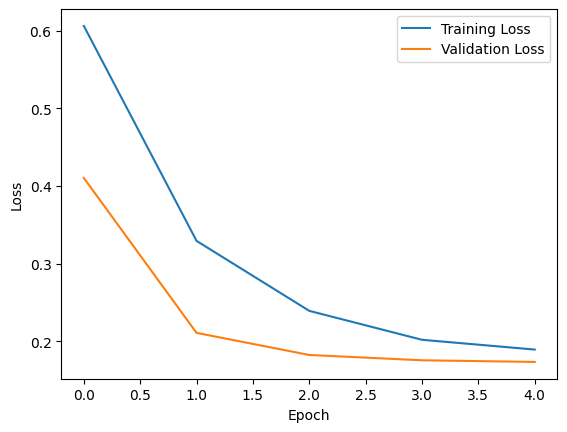

In [ ]:
import matplotlib.pyplot as plt

# Extract loss from log history
training_loss = [log["loss"] for log in trainer.state.log_history if "loss" in log]
validation_loss = [log["eval_loss"] for log in trainer.state.log_history if "eval_loss" in log]

# Plotting
plt.plot(training_loss, label="Training Loss")
plt.plot(validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
model.save_pretrained("Mbert-political-news-classifier")
tokenizer.save_pretrained("Mbert-political-news-classifier_teacher")

('Mbert-political-news-classifier_teacher/tokenizer_config.json',
 'Mbert-political-news-classifier_teacher/special_tokens_map.json',
 'Mbert-political-news-classifier_teacher/vocab.txt',
 'Mbert-political-news-classifier_teacher/added_tokens.json',
 'Mbert-political-news-classifier_teacher/tokenizer.json')

In [ ]:
# Mendapatkan label asli dari data uji
y_true = tokenized_data["test"]["label"]

In [ ]:
# Melakukan prediksi pada data uji
predictions = trainer.predict(tokenized_data["validation"])
y_pred = predictions.predictions.argmax(axis=1)

In [ ]:
cleaned_data = tokenized_data["validation"]["cleaned"]

# Membuat DataFrame dengan hasil prediksi dan data 'cleaned'
results_df = pd.DataFrame({
    'cleaned': cleaned_data,
    'label': predictions.label_ids,  # Assuming 'label_ids' contains the true labels
    'prediction': y_pred
})

# Menampilkan tabel
display(results_df)

,cleaned,label,prediction
0,prabowo gugat polri soal penangkapan aktivis k...,1,1
1,ronaldo pamer jersey berlogo partai golkar ron...,1,1
2,fahri hamzah sebut aniesrk tak punya fulus maj...,0,0
3,olase foto wong iklan caleg pks isinya poligam...,1,1
4,ulama windusari dijemput paksa terkait covid p...,1,1
...,...,...,...
385,ancaman krisis ekonomi sby saya ingin membantu...,1,0
386,fahri hamzah soal bbm naik rakyat tak terima s...,0,0
387,survei populi center persen masyarakat bangga ...,1,1
388,prabowo mengundurkan diri dari jabatannya akun...,1,1


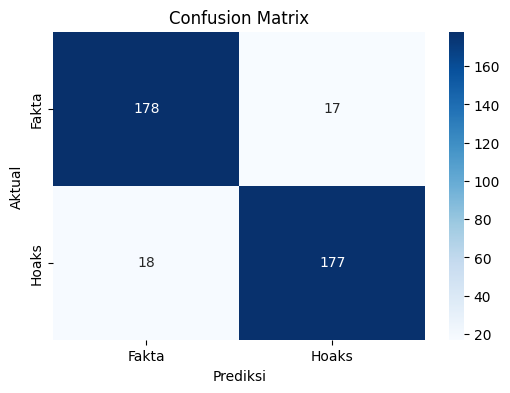

In [ ]:
# Mendapatkan label asli dari data validation, bukan data test!
y_true = tokenized_data["validation"]["label"]

# 1. Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix  # Import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fakta", "Hoaks"], yticklabels=["Fakta", "Hoaks"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# 2. Classification Report
from sklearn.metrics import classification_report # Import the classification_report function

print(classification_report(y_true, y_pred, target_names=["Fakta", "Hoaks"]))

              precision    recall  f1-score   support

       Fakta       0.91      0.91      0.91       195
       Hoaks       0.91      0.91      0.91       195

    accuracy                           0.91       390
   macro avg       0.91      0.91      0.91       390
weighted avg       0.91      0.91      0.91       390



In [ ]:
# 3. ROC AUC Score
from sklearn.metrics import roc_auc_score
print("ROC AUC Score:", roc_auc_score(y_true, y_pred))

ROC AUC Score: 0.9102564102564101


In [ ]:
# Evaluasi model pada dataset uji
eval_result = trainer.evaluate()
print("Hasil Evaluasi:", eval_result)

Hasil Evaluasi: {'eval_loss': 0.17326931655406952, 'eval_Accuracy': 0.934, 'eval_AUC': 0.982, 'eval_runtime': 11.1088, 'eval_samples_per_second': 35.467, 'eval_steps_per_second': 1.17, 'epoch': 5.0}
